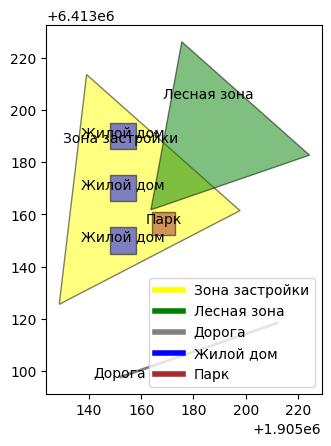

In [26]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import json
from pyproj import CRS, Transformer
from shapely.geometry import shape, Polygon
from shapely.ops import transform

# Загрузка данных
with open('input.geojson') as f:
    geo_data = json.load(f)

# Преобразование GeoJSON в GeoDataFrame с извлечением свойств
features = geo_data["features"]
for feature in features:
    feature['geometry'] = shape(feature['geometry'])

gdf = gpd.GeoDataFrame(features)
gdf['name'] = gdf['properties'].apply(lambda x: x['name'])
gdf['restriction'] = gdf['properties'].apply(lambda x: x.get('restriction', None))

# Преобразование координат
wgs84 = CRS("EPSG:4326")  # Координаты в долготе и широте
utm = CRS("EPSG:32633")   # Координаты в метрах

transformer = Transformer.from_crs(wgs84, utm, always_xy=True)
gdf['geometry'] = gdf['geometry'].apply(lambda geom: transform(transformer.transform, geom))

# Ограничения по плотности застройки
max_density = 0.5  # 50%

# Минимальное расстояние между объектами для домов
min_distance = 10  # метров

# Назначение цветов для разных типов зон
color_map = {
    'Зона застройки': 'yellow',
    'Лесная зона': 'green',
    'Дорога': 'gray',
    'Жилой дом': 'blue',
    'Парк': 'brown'
}

# Функция проверки, можно ли строить в заданной точке
def can_build_at_point(polygon, gdf):
    for _, row in gdf.iterrows():
        if row['geometry'].intersects(polygon) and row['restriction'] == 'no_build':
            return False
    return True

# Функция для размещения нескольких домов с ограничением по расстоянию между строениями
def place_multiple_houses(gdf, build_zone, house_size, max_density):
    buildings = []
    build_area = build_zone.iloc[0]['geometry'].area
    max_build_area = build_area * max_density

    current_build_area = 0
    minx, miny, maxx, maxy = build_zone.total_bounds

    for x in range(int(minx), int(maxx - house_size), house_size + min_distance):
        for y in range(int(miny), int(maxy - house_size), house_size + min_distance):
            house_polygon = Polygon([(x, y), (x + house_size, y), (x + house_size, y + house_size), (x, y + house_size)])
            if build_zone.iloc[0]['geometry'].contains(house_polygon) and can_build_at_point(house_polygon, gdf):
                buildings.append(house_polygon)
                current_build_area += house_polygon.area
                if current_build_area >= max_build_area:
                    break

    return buildings

# Функция для размещения парка без учета существования лесной зоны и ограничения по расстоянию
def place_park(gdf, build_zone, park_size):
    park = None
    build_polygon = build_zone.iloc[0]['geometry']

    minx, miny, maxx, maxy = build_polygon.bounds
    for x in range(int(minx), int(maxx - park_size), park_size):
        for y in range(int(miny), int(maxy - park_size), park_size):
            park_polygon = Polygon([(x, y), (x + park_size, y), (x + park_size, y + park_size), (x, y + park_size)])
            if build_polygon.contains(park_polygon) and can_build_at_point(park_polygon, gdf):
                if not any(building.intersects(park_polygon) for building in gdf[gdf['name'] == 'Жилой дом']['geometry']):
                    park = park_polygon
                    break

    return park

# Определение зоны застройки
build_zone = gdf[gdf['name'] == 'Зона застройки']

# Размещение нескольких домов
house_size = 10  # размер дома 10 на 10 метров
buildings = place_multiple_houses(gdf, build_zone, house_size, max_density)

# Добавление объектов в GeoDataFrame
buildings_gdf = gpd.GeoDataFrame([{'geometry': building, 'name': 'Жилой дом', 'restriction': None} for building in buildings])
gdf = pd.concat([gdf, buildings_gdf], ignore_index=True)

# Размещение парка
park_size = 9  # размер парка 9 на 9 метров
park = place_park(gdf, build_zone, park_size)

if park is not None:
    park_gdf = gpd.GeoDataFrame([{'geometry': park, 'name': 'Парк', 'restriction': None}])
    gdf = pd.concat([gdf, park_gdf], ignore_index=True)

# Отрисовка графика с цветами
fig, ax = plt.subplots()
for _, row in gdf.iterrows():
    geom_type = row['geometry'].geom_type
    color = color_map.get(row['name'], 'black')
    if geom_type == 'Polygon':
        gdf[gdf.geometry == row['geometry']].plot(ax=ax, color=color, edgecolor='black', alpha=0.5)
    elif geom_type == 'LineString':
        gdf[gdf.geometry == row['geometry']].plot(ax=ax, color=color, linewidth=2)

# Добавление подписи для каждого участка
for _, row in gdf.iterrows():
    coords = row['geometry'].representative_point().coords[0]
    plt.text(coords[0], coords[1], row['name'], horizontalalignment='center', fontsize=10)

# Легенда
legend_labels = [plt.Line2D([0], [0], color=color_map[name], lw=4) for name in color_map]
legend_names = list(color_map.keys())
plt.legend(legend_labels, legend_names)

plt.show()

